In [34]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/curated/master_modelling_table.parquet")

print(df.shape)
df.head()

(11943, 85)


,listing_id,suburb,postcode,lat,lon,weekly_rent,bond,available_date,date_listed,days_listed,...,income_skew_ratio,income_reliable,population_density_2026,is_modelling_ready,n_schools,n_primary_schools,n_secondary_schools,n_government_schools,n_stations,n_stations_both_networks
0,16782629,SOUTH KINGSVILLE,3015,-37.830982,144.87091,460.0,1994.0,"Tuesday, 02 September 2025",2025-08-13,27.0,...,1.203772,True,2299.934248,True,5,5,0,3,3,0
1,17471867,SOUTH KINGSVILLE,3015,-37.826218,144.86755,400.0,1738.0,"Thursday, 27 March 2025",2025-03-06,187.0,...,1.203772,True,2299.934248,True,5,5,0,3,3,0
2,17721851,SOUTH KINGSVILLE,3015,-37.831226,144.86632,795.0,3454.0,"Monday, 15 September 2025",2025-08-19,21.0,...,1.234966,True,1029.407548,True,5,4,1,1,0,0
3,17725855,SOUTH KINGSVILLE,3015,-37.827423,144.86768,675.0,2933.0,"Wednesday, 20 August 2025",2025-08-21,19.0,...,1.203772,True,2299.934248,True,5,5,0,3,3,0
4,17745057,SOUTH KINGSVILLE,3015,-37.826270,144.86790,450.0,1955.0,"Tuesday, 02 September 2025",2025-09-03,6.0,...,1.203772,True,2299.934248,True,5,5,0,3,3,0


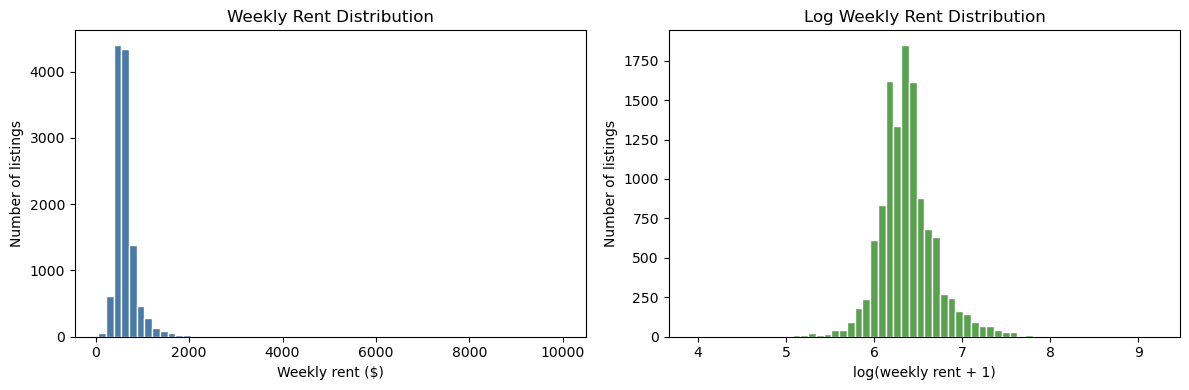

In [35]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["weekly_rent"], bins=60, color="#4a7ba7", edgecolor="white")
axes[0].set_title("Weekly Rent Distribution")
axes[0].set_xlabel("Weekly rent ($)")
axes[0].set_ylabel("Number of listings")

axes[1].hist(np.log1p(df["weekly_rent"]), bins=60, color="#59a14f", edgecolor="white")
axes[1].set_title("Log Weekly Rent Distribution")
axes[1].set_xlabel("log(weekly rent + 1)")
axes[1].set_ylabel("Number of listings")

plt.tight_layout()
plt.show()

In [36]:
numeric_features = [
    "bedrooms", "bathrooms", "carspaces",
    "route_km_to_cbd",
    "est_route_km_to_nearest_station",
    "straight_km_to_nearest_school",
    "straight_km_to_nearest_park",
    "straight_km_to_nearest_mall",
    "n_stations_within_1km",
    "n_schools_within_1km",
    "n_parks_within_500m",
    "income_median",
    "population_growth_5y",
    "population_density_2026",
]

categorical_features = [
    "primary_type",
    "suburb",
]

In [37]:
features = numeric_features + categorical_features
X = df[features].copy()

missing_summary = (
    X.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(X) * 100
)

missing_summary

,missing_count,missing_percentage
bedrooms,0,0.0
bathrooms,0,0.0
carspaces,0,0.0
route_km_to_cbd,0,0.0
est_route_km_to_nearest_station,0,0.0
straight_km_to_nearest_school,0,0.0
straight_km_to_nearest_park,0,0.0
straight_km_to_nearest_mall,0,0.0
n_stations_within_1km,0,0.0
n_schools_within_1km,0,0.0


In [38]:
features = numeric_features + categorical_features

X = df[features].copy()
y = np.log1p(df["weekly_rent"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11943, 16)
y shape: (11943,)


In [39]:
X = df[features].copy()
y = np.log1p(df["weekly_rent"])

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (9554, 16)
Test: (2389, 16)


In [41]:
 from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [42]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred_log = pipe.predict(X_test)

    y_test_rent = np.expm1(y_test)
    y_pred_rent = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test_rent, y_pred_rent)
    rmse = mean_squared_error(y_test_rent, y_pred_rent, squared=False)
    r2 = r2_score(y_test_rent, y_pred_rent)

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,model,MAE,RMSE,R2
1,Random Forest,74.66091,152.583824,0.691374
2,Gradient Boosting,85.25861,172.551676,0.605312
0,Ridge Regression,87.39253,185.406892,0.544312


In [44]:
best_model_name = results_df.iloc[0]["model"]
best_model_name

'Random Forest'

In [45]:
best_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'carspaces',
                                                   'route_km_to_cbd',
                                                   'est_route_km_to_nearest_station',
                                                   'straight_km_to_nearest_school',
                                                   'straight_km_to_nearest_park',
                                                   'straight_km_to_nearest_mall',
                                                   'n_stati...km',
                                                   'n_schools_within_1km',
                                                   'n_parks_within_500m',
                                                   'income_median',
                                                   'population_growth_5y',
                                                   'population_density_2026']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['primary_type',
                                                   'suburb'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [46]:
feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()

importances = best_pipe.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
3,num__route_km_to_cbd,0.328030
1,num__bathrooms,0.174443
0,num__bedrooms,0.165334
12,num__population_growth_5y,0.039306
11,num__income_median,0.038340
4,num__est_route_km_to_nearest_station,0.030991
7,num__straight_km_to_nearest_mall,0.030447
6,num__straight_km_to_nearest_park,0.029776
5,num__straight_km_to_nearest_school,0.028087
13,num__population_density_2026,0.023496


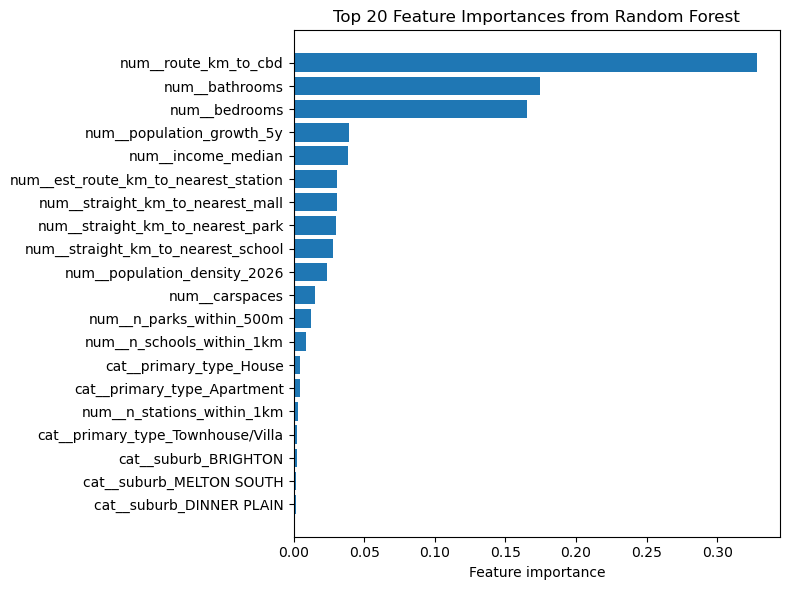

In [47]:
top_n = 20
top_features = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.title("Top 20 Feature Importances from Random Forest")
plt.tight_layout()
plt.show()

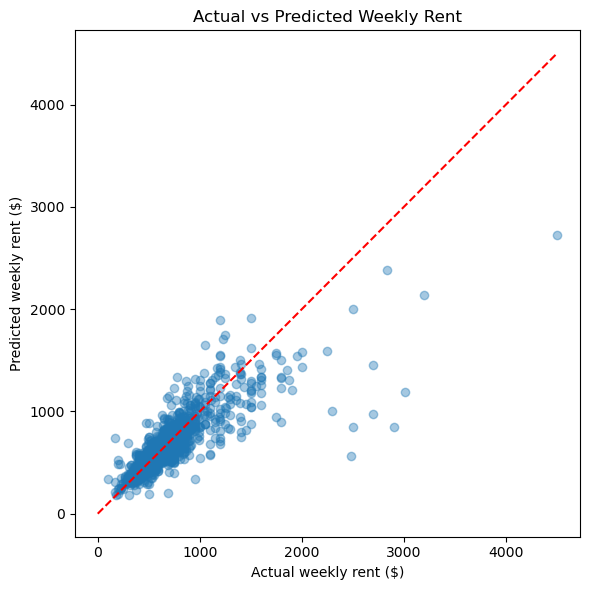

In [48]:
y_pred_log = best_pipe.predict(X_test)

y_test_rent = np.expm1(y_test)
y_pred_rent = np.expm1(y_pred_log)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_rent, y_pred_rent, alpha=0.4)

max_rent = max(y_test_rent.max(), y_pred_rent.max())
plt.plot([0, max_rent], [0, max_rent], color="red", linestyle="--")

plt.xlabel("Actual weekly rent ($)")
plt.ylabel("Predicted weekly rent ($)")
plt.title("Actual vs Predicted Weekly Rent")
plt.tight_layout()
plt.show()